# <center>Lecture 10: Dynamic discrete choice, infinite horizon</center>
### <center>Alfred Galichon (NYU)</center>
## <center>'math+econ+code' masterclass series: discrete choice</center>
#### <center>With python code examples</center>

© 2026 by Alfred Galichon. Past and present support from NSF grant DMS-1716489, ERC grant CoG-866274 are acknowledged, as well as inputs from contributors listed [here](http://www.math-econ-code.org/team).

**If you reuse material from this masterclass, please cite as:**<br>
Alfred Galichon, 'math+econ+code' masterclass series. https://www.math-econ-code.org/

This notebook is the **computational companion to chapter 6, sections 6.5–6.8** of

> A. Galichon, *Discrete Choice Models: Mathematical Methods, Econometrics, and Data Science*, Princeton University Press, 2026,

covering the model with infinite horizon (6.5), inference in the logit model with infinite horizon (6.6), nonparametric identification (6.7), and the conditional choice probability approach (6.8). It runs the book's code listings `6-05`, `6-06`, `6-07` and `6-08`. Slide deck: folders `ch6/ch6.5`–`ch6/ch6.8`.

### Learning objectives

* Why the value function stops depending on time, and why the backward recursion of lecture 9 becomes a **fixed point** — a contraction with modulus $\beta$.
* The **stationary distribution** $n^\star$ as a Perron eigenvector, reached geometrically from any starting point.
* The **nested fixed-point** maximum likelihood estimator: the derivative $du/d\lambda$ from the implicit function theorem, the second differential from a row-wise Kronecker product, and the sandwich covariance.
* The same estimator written as an **MPEC**, and solved by an augmented Lagrangian in which the multiplier on the Bellman constraint *is* the mass of units in each state.
* **Nonparametric identification**: the identified set is an affine subspace of dimension $X$; identified statistics; identifying restrictions.
* Hotz and Miller's **conditional choice probability** estimator as a closed-form demand inversion — and what it costs in efficiency and robustness.
* Estimating the model on **Rust's bus-engine data**.

### References

* Galichon (2026). *Discrete Choice Models*. Princeton University Press. **Chapter 6, sections 6.5–6.8**.
* Rust (1987). "Optimal Replacement of GMC Bus Engines: An Empirical Model of Harold Zurcher". *Econometrica* 55(5), 999–1033. The data of section 6, and the nested fixed-point algorithm of section 2.
* Hotz and Miller (1993). "Conditional Choice Probabilities and the Estimation of Dynamic Models". *Review of Economic Studies* 60(3), 497–529. Section 5.
* Su and Judd (2012). "Constrained Optimization Approaches to Estimation of Structural Models". *Econometrica* 80(5), 2213–2230. The MPEC formulation of section 3.
* Aguirregabiria and Mira (2002). "Swapping the Nested Fixed Point Algorithm". *Econometrica* 70(4), 1519–1543.
* Magnac and Thesmar (2002). "Identifying Dynamic Discrete Decision Processes". *Econometrica* 70(2), 801–816. The identification results of section 4, and the near-flatness in $\beta$ that section 6 measures.
* Chiong, Galichon and Shum (2016). "Duality in Dynamic Discrete Choice Models". *Quantitative Economics* 7, 83–115.
* Previous lectures: `dc09_dynamic-discrete-choice-finite-horizon` (the linear program over occupation measures, and the potential $Z$, both of which reappear here); `dc01_random-utility-welfare-and-inversion` (demand inversion, which section 5 performs in a dynamic setting); `dc03_logistic-regression-and-the-glm-connection` (moment matching, which section 3 recovers as a first-order condition).
* Companion m+e+c notebooks: `rp02_rust` for a fuller replication of Rust (1987); `dp02_tbc_markov-decision-processes` for the dynamic-programming series.

## Motivation: the recursion becomes a fixed point

Lecture 9 solved a $T$-period problem by backward induction from a terminal condition. Take $T\to\infty$ and the terminal condition disappears; what replaces it is a *self-consistency* requirement. The value of being in state $x$ is the log-sum-exp of the immediate payoffs plus the discounted value of where each decision leads:
$$u_{x}=\log\sum_{y\in[Y]}\exp\big(\phi_{xy}+\beta(\mathbf{P}^\top u)_{xy}\big).$$
This is one equation per state, and $u$ appears on both sides. Blackwell's theorem says the map on the right is a $\beta$-contraction, so it has a unique bounded solution, reached geometrically from anywhere. Section 1 measures that rate and finds exactly $\beta$.

Everything downstream is a consequence of that one change. In vectorized form, with
$$\mathbf{\Sigma}_Y:=\mathbf{I}_X\otimes\mathbf{1}_Y^\top,\qquad \mathbf{\Psi}:=\beta\mathbf{P}^\top-\mathbf{\Sigma}_Y^\top,$$
the fixed point reads $\mathbf{\Sigma}_Y\exp(\Phi\lambda+\mathbf{\Psi}u)=\mathbf{1}_X$ and the choice probabilities are $\pi=\exp(\Phi\lambda+\mathbf{\Psi}u)$. Two matrices, and the whole chapter is written in them.

**Three routes to the same estimator.** The log-likelihood is $\ell(\lambda)=\hat\mu^\top(\Phi\lambda+\mathbf{\Psi}u^\lambda)$, and one may (i) solve the fixed point at every $\lambda$ and differentiate through it — Rust's **nested fixed point**; (ii) treat $u$ as a free parameter and the fixed point as a constraint — the **MPEC** of Su and Judd, whose multiplier turns out to be the mass of units in each state; or (iii) skip the parameter and invert the observed choice probabilities directly — **Hotz and Miller**. The first two give the same numbers to eight decimals. The third gives a closed form, and pays for it.

**What is identified.** Equation $\log\pi=\phi+\mathbf{\Psi}u$ is $XY$ equations in $XY+X$ unknowns, so $\phi$ is identified only up to an $X$-dimensional affine subspace. Section 4 makes that set explicit; section 5 picks the point in it satisfying $\phi_{x1}=0$. Section 6 shows what happens when the data are Harold Zurcher's.

In [1]:
import numpy as np
from scipy import optimize
import matplotlib.pyplot as plt

rng = np.random.default_rng(10)         # lecture number
FAST_MODE = True

np.set_printoptions(precision=4, suppress=True)

## 1. The stationary problem

The primal problem of theorem 6.5 is the lecture-9 linear program pushed to an infinite horizon, with discounting inside the objective:
$$\max_{\mu_{txy}\ge0}\ \sum_{txy}\beta^{t-1}\Big(\mu_{txy}\phi_{xy}-\mu_{txy}\log\frac{\mu_{txy}}{\sum_y\mu_{txy}}\Big)$$
subject to $\sum_y\mu_{1xy}=N_x$ and the flow equations $\sum_{x'y}P_{x,x'y}\mu_{tx'y}=\sum_y\mu_{(t+1)xy}$. Its dual is
$$\min_u\ \sum_xN_xu_{1x}\quad\text{s.t.}\quad u_{tx}=\log\sum_y\exp\big(\phi_{xy}+\beta(\mathbf{P}^\top u_{t+1})_{xy}\big),$$
and the proposition following it says the dual solution is **time-invariant**: $u_{tx}=u_x$. The proof is a contraction argument, and it is worth checking numerically rather than taking on faith.

**The model.** Harold Zurcher again, but now forever. A bus engine is in one of $X=10$ mileage brackets of 5,000 miles. Each period the manager either keeps it ($y=1$) or replaces it ($y=2$), after which the odometer is reset. Mileage advances by $0$, $1$ or $2$ brackets with probabilities $(0.30,0.50,0.20)$, and the top bracket absorbs. The short-term payoff is linear in a parameter $\lambda\in\mathbb{R}^3$:
$$\phi_{x,\text{keep}}=-\lambda_1x-\lambda_2x^2/10,\qquad \phi_{x,\text{replace}}=-\lambda_3,$$
so $\lambda_1$ and $\lambda_2$ are operating costs rising in mileage and $\lambda_3$ is the cost of a new engine. We take $\lambda=(0.30,\,0.05,\,4.0)$ and $\beta=0.9$.

In [2]:
X, Y, K = 10, 2, 3
beta = 0.9
KEEP, REPL = 0, 1                        # y = 1 and y = 2 in the book's numbering

# transitions: P[x', x*Y+y] = Prob(next state x' | state x, decision y)
inc_p = np.array([0.30, 0.50, 0.20])
P_xp_xy = np.zeros((X, X * Y))
for x in range(X):
    for d, p in enumerate(inc_p):
        P_xp_xy[min(x + d, X - 1), x * Y + KEEP] += p     # mileage accumulates
        P_xp_xy[min(d,     X - 1), x * Y + REPL] += p     # odometer reset, then accumulates
assert np.allclose(P_xp_xy.sum(axis=0), 1)

# payoffs: Phi is XY x K, phi = Phi @ lambda
Phi = np.zeros((X * Y, K))
Phi[KEEP::Y, 0] = -np.arange(X)
Phi[KEEP::Y, 1] = -np.arange(X) ** 2 / 10.0
Phi[REPL::Y, 2] = -1.0
lam_true = np.array([0.30, 0.05, 4.0])
phi_true = Phi @ lam_true

SigmaY = np.kron(np.eye(X), np.ones((1, Y)))     #  X  x XY , sums over y
Psi = beta * P_xp_xy.T - SigmaY.T                # XY  x  X

print('Sigma_Y is', SigmaY.shape, 'and Psi is', Psi.shape)
print('phi(keep)   :', phi_true[KEEP::Y])
print('phi(replace):', phi_true[REPL::Y])

Sigma_Y is (10, 20) and Psi is (20, 10)
phi(keep)   : [ 0.    -0.305 -0.62  -0.945 -1.28  -1.625 -1.98  -2.345 -2.72  -3.105]
phi(replace): [-4. -4. -4. -4. -4. -4. -4. -4. -4. -4.]


### The Bellman operator is a $\beta$-contraction

We solve $\mathbf{\Sigma}_Y\exp(\phi+\mathbf{\Psi}u)=\mathbf{1}_X$ by iterating the map, in the log-sum-exp-stable form used by listing `6-05`. The listing runs a fixed number of iterations
$$S=\max\Big(\frac{\log\varepsilon-2M}{\log\beta},\,10\Big),\qquad M=1+\frac{|\phi|_\infty+\log Y}{1-\beta},$$
with no early exit; $M$ is the bound on $|u|_\infty$ from the proof of the proposition. We iterate to a residual instead, and compare.

In [3]:
def bellman(phi, bet=beta, tol=1e-13, maxit=20000, trace=False):
    '''Solve u_x = log sum_y exp(phi_xy + beta (P'u)_xy) by iteration.'''
    u, hist = np.zeros(X), []
    for s in range(maxit):
        v = (phi + bet * (P_xp_xy.T @ u)).reshape((X, Y))
        m = v.max(axis=1)                                   # stabilized log-sum-exp
        u_new = m + np.log(np.exp(v - m[:, None]).sum(axis=1))
        hist.append(np.abs(u_new - u).max())
        u = u_new
        if hist[-1] < tol:
            break
    return (u, np.array(hist)) if trace else u

u_true, hist = bellman(phi_true, trace=True)
pi_true = np.exp(phi_true + Psi @ u_true)

print('u* =', u_true)
print('residual of the fixed point   :', np.abs(SigmaY @ pi_true - 1).max())
print('P(replace | x)                :', pi_true[REPL::Y])

ratios = hist[21:200] / hist[20:199]           # above machine precision
print(f'\niterations to 1e-13: {len(hist)}')
print(f'contraction ratio |u^(s+1)-u^s| / |u^s-u^(s-1)|: '
      f'{ratios[:3]} ... {ratios[-3:]}  (beta = {beta})')
print(f'max deviation from beta over s = 20..200: {np.abs(ratios - beta).max():.2e}')

print(f"\n{'beta':>6}{'iterations needed':>19}{'listing 6-05 S':>16}{'factor':>9}")
for bet in (0.5, 0.9, 0.99):
    _, h_b = bellman(phi_true, bet=bet, trace=True)
    M = 1 + (np.abs(phi_true).max() + np.log(Y)) / (1 - bet)
    S = int(max((np.log(1e-13) - 2 * M) / np.log(bet), 10))
    print(f'{bet:>6}{len(h_b):>19}{S:>16}{S / len(h_b):>9.1f}')
assert np.abs(ratios - beta).max() < 1e-4

u* = [ -7.9037  -8.9478  -9.7854 -10.4219 -10.8839 -11.2093 -11.4349 -11.5901
 -11.695  -11.7648]
residual of the fixed point   : 8.58202398035246e-14
P(replace | x)                : [0.018  0.0511 0.1181 0.2231 0.3542 0.4904 0.6145 0.7177 0.797  0.8546]

iterations to 1e-13: 286
contraction ratio |u^(s+1)-u^s| / |u^s-u^(s-1)|: [0.9 0.9 0.9] ... [0.9 0.9 0.9]  (beta = 0.9)
max deviation from beta over s = 20..200: 8.61e-06

  beta  iterations needed  listing 6-05 S   factor
   0.5                 45              73      1.6
   0.9                286            1193      4.2
  0.99               2983           96570     32.4


The ratio of successive increments settles on $\beta=0.9$ to within $10^{-5}$: the operator contracts at exactly the discount factor, not merely at some rate bounded by it.

The a priori count $S$ is safe but wasteful, and increasingly so as the agent grows patient: at $\beta=0.9$ it asks for four times the iterations actually needed, and at $\beta=0.99$ for **thirty-two times**. The reason is visible in the formula — $M$ carries a factor $(1-\beta)^{-1}$ and then enters $S$ divided by $\log\beta$, so the bound degrades quadratically in $(1-\beta)^{-1}$ while the true count degrades only linearly. Since the fixed point sits inside the estimation loop of section 2, that factor multiplies the cost of every likelihood evaluation. A residual-based stop is worth the two extra lines.

### The horizon, and where lecture 9 ends up

The proposition says the finite-horizon value functions converge to $u^\star$. We can watch it happen: run the backward recursion of lecture 9 from $u_{T+1}=0$ and look at $u_1$.

In [4]:
for T in (5, 10, 20, 40, 80):
    u_bwd = np.zeros(X)
    for t in range(T):
        v = (phi_true + beta * (P_xp_xy.T @ u_bwd)).reshape((X, Y))
        m = v.max(axis=1)
        u_bwd = m + np.log(np.exp(v - m[:, None]).sum(axis=1))
    err = np.abs(u_bwd - u_true).max()
    print(f'horizon T = {T:>3}: |u_1 - u*|_inf = {err:.3e}   '
          f'beta^T |u*|_inf = {beta ** T * np.abs(u_true).max():.3e}')

horizon T =   5: |u_1 - u*|_inf = 6.090e+00   beta^T |u*|_inf = 6.947e+00
horizon T =  10: |u_1 - u*|_inf = 3.569e+00   beta^T |u*|_inf = 4.102e+00
horizon T =  20: |u_1 - u*|_inf = 1.244e+00   beta^T |u*|_inf = 1.430e+00
horizon T =  40: |u_1 - u*|_inf = 1.512e-01   beta^T |u*|_inf = 1.739e-01
horizon T =  80: |u_1 - u*|_inf = 2.235e-03   beta^T |u*|_inf = 2.570e-03


The truncation error is not merely $O(\beta^T)$ — it is $0.87\,\beta^T|u^\star|_\infty$, the same constant at every horizon, which is what a geometric rate with no transient looks like. Forty periods leave an error of $0.15$; eighty leave $0.002$. The two lectures describe the same object at different truncations.

### The stationary distribution

The choice probabilities $\pi_{xy}$ are time-invariant, but the masses $n_{tx}=\sum_y\mu_{txy}$ are not: they evolve as $n_{t+1}=\mathbf{Q}n_t$ with
$$Q_{x'x}=\sum_yP_{x',xy}\pi_{xy}.$$
The theorem following definition 6.6 uses Perron–Frobenius: $\mathbf{1}_X^\top\mathbf{Q}=\mathbf{1}_X^\top$ so the Perron eigenvalue is 1, and the right Perron eigenvector $n^\star$ is the stationary distribution, approached from any starting point.

In [5]:
Q = (P_xp_xy * pi_true[None, :]).reshape(X, X, Y).sum(axis=2)   # Q[x', x]
print('columns of Q sum to one:', np.abs(Q.sum(axis=0) - 1).max())

w, V = np.linalg.eig(Q)
order = np.argsort(-np.abs(w))
print('two largest eigenvalues in modulus:', np.abs(w[order[:2]]))
n_star = np.abs(V[:, order[0]].real)
n_star /= n_star.sum()
print('n* =', n_star)
print('Q n* = n* ?', np.abs(Q @ n_star - n_star).max())

# the flow equation of the stationary solution, in terms of mu
mu_star = (n_star[:, None] * pi_true.reshape(X, Y)).flatten()
print('flow equation  P mu = n :', np.abs(P_xp_xy @ mu_star - n_star).max())

# convergence from a degenerate start: every engine begins in the worst bracket
n_t, devs = np.zeros(X), []
n_t[X - 1] = 1.0
for t in range(60):
    devs.append(np.abs(n_t - n_star).sum())
    n_t = Q @ n_t
devs = np.array(devs)
print(f'\n|n_t - n*|_1 at t = 0, 5, 10, 20: '
      f'{devs[0]:.4f}, {devs[5]:.4f}, {devs[10]:.5f}, {devs[20]:.2e}')
print(f'observed rate over t = 5..20: {(devs[20] / devs[5]) ** (1 / 15):.4f}, '
      f'second eigenvalue modulus: {np.abs(w[order[1]]):.4f}')

columns of Q sum to one: 8.58202398035246e-14
two largest eigenvalues in modulus: [1.     0.5741]
n* = [0.092  0.2143 0.2216 0.1804 0.1354 0.0847 0.0442 0.0187 0.0064 0.0023]
Q n* = n* ? 1.892930256985892e-14
flow equation  P mu = n : 1.8957058145474548e-14

|n_t - n*|_1 at t = 0, 5, 10, 20: 1.9954, 0.1160, 0.00679, 2.63e-05
observed rate over t = 5..20: 0.5716, second eigenvalue modulus: 0.5741


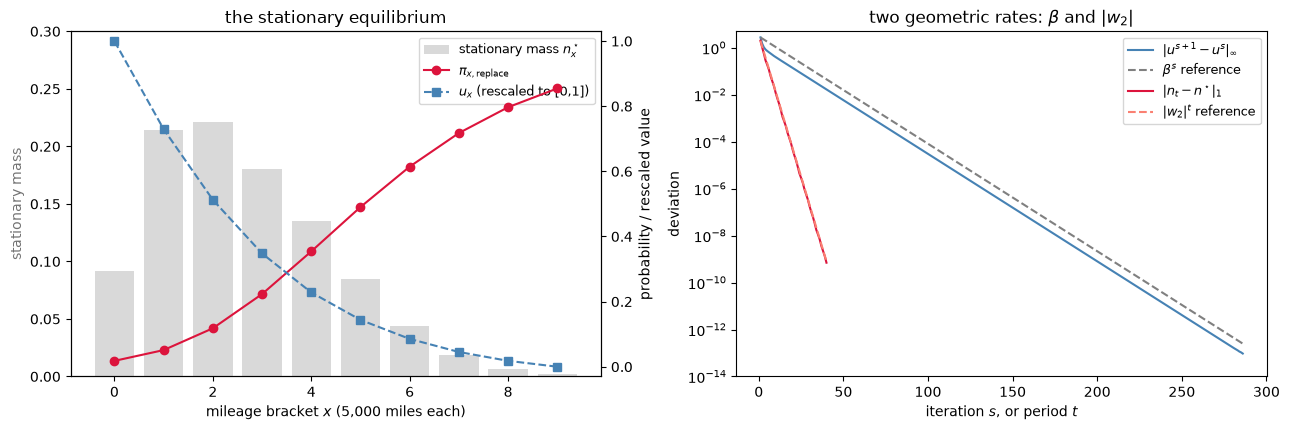

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))

a = ax[0]
a.bar(np.arange(X), n_star, color='0.85', label='stationary mass $n^\\star_x$')
a.set_xlabel('mileage bracket $x$ (5,000 miles each)')
a.set_ylabel('stationary mass', color='0.45')
a.set_ylim(0, 0.30)
a2 = a.twinx()
a2.plot(np.arange(X), pi_true[REPL::Y], 'o-', color='crimson',
        label='$\\pi_{x,\\mathrm{replace}}$')
a2.plot(np.arange(X), (u_true - u_true.min()) / (u_true.max() - u_true.min()),
        's--', color='steelblue', label='$u_x$ (rescaled to [0,1])')
a2.set_ylabel('probability / rescaled value')
a2.set_ylim(-0.03, 1.03)
h1, l1 = a.get_legend_handles_labels()
h2, l2 = a2.get_legend_handles_labels()
a.legend(h1 + h2, l1 + l2, loc='upper right', fontsize=9)
a.set_title('the stationary equilibrium')

b = ax[1]
b.semilogy(np.arange(1, len(hist) + 1), hist, color='steelblue',
           label='$|u^{s+1}-u^{s}|_\\infty$')
b.semilogy(np.arange(1, len(hist) + 1), hist[0] * beta ** np.arange(len(hist)),
           '--', color='0.5', label='$\\beta^{s}$ reference')
b.semilogy(np.arange(1, 41), devs[:40], color='crimson',
           label='$|n_t-n^\\star|_1$')
b.semilogy(np.arange(1, 41), devs[0] * np.abs(w[order[1]]) ** np.arange(40),
           '--', color='salmon', label='$|w_2|^{t}$ reference')
b.set_xlabel('iteration $s$, or period $t$')
b.set_ylabel('deviation')
b.set_ylim(1e-14, 5)
b.legend(fontsize=9)
b.set_title('two geometric rates: $\\beta$ and $|w_2|$')

plt.tight_layout()
plt.show()

*Left.* The stationary equilibrium. The mass of engines concentrates in brackets 1–3 — the modal engine has 5,000 to 15,000 miles on it — and thins out above bracket 6, because an engine that reaches high mileage is replaced with high probability and returns to the bottom. The replacement probability rises from $0.018$ at bracket 0 to $0.855$ at bracket 9, and the value function (rescaled here to fit the same axis) falls monotonically in mileage: $u_0=-7.90$ against $u_9=-11.76$.

*Right.* The two geometric rates that govern the model, on the same axes. The Bellman iteration contracts at $\beta=0.9$, tracking its reference line for thirteen decades until it hits machine precision. The distribution converges much faster, at $|w_2|=0.574$: the *value* iteration is slow because $\beta$ is a preference parameter, while the *distribution* converges at a rate set by how quickly the Markov chain mixes, which here is a property of the technology. These are different numbers and they are often confused.

## 2. Maximum likelihood by nested fixed point

Observations are $I$ independent draws of a pair $(x_i,y_i)$ from the stationary population. Collecting them into counts $\hat\mu_{xy}$, the log-likelihood is
$$\ell(\lambda)=\hat\mu^\top\big(\Phi\lambda+\mathbf{\Psi}u^\lambda\big),$$
and the maximum likelihood estimator maximizes it. The only difficulty is that $u^\lambda$ is defined implicitly. Differentiating $\mathbf{\Sigma}_Y\exp(\Phi\lambda+\mathbf{\Psi}u)=\mathbf{1}_X$ gives $\mathbf{\Sigma}_Y\mathbf{\Delta}_\pi(\Phi+\mathbf{\Psi}\,du)=0$, hence
$$du=-(\mathbf{\Sigma}_Y\mathbf{\Delta}_\pi\mathbf{\Psi})^{-1}\mathbf{\Sigma}_Y\mathbf{\Delta}_\pi\Phi,$$
where $\mathbf{\Delta}_\pi=\mathrm{diag}(\pi)$. Differentiating once more, and writing $M^{\circledast2}$ for the row-wise Kronecker product of $M$ with itself,
$$d^2u=-(\mathbf{\Sigma}_Y\mathbf{\Delta}_\pi\mathbf{\Psi})^{-1}\mathbf{\Sigma}_Y\mathbf{\Delta}_\pi\big((\Phi+\mathbf{\Psi}du)^{\circledast2}\big).$$
Since $d\log\pi=\Phi+\mathbf{\Psi}du$, the score is simply $d\ell=\hat\mu^\top d\log\pi$ — which is what one would write down for any multinomial likelihood, and the dynamics are entirely inside $du$.

In [7]:
# --- simulate a sample from the stationary population
I = 20000
muhat = rng.multinomial(I, mu_star).astype(float)
print('counts by (bracket, decision):')
print(np.column_stack([np.arange(X), muhat.reshape(X, Y)]))
print('smallest cell:', muhat.min(), ' expected under the model:',
      round(I * mu_star.min(), 1))


def u_of(lam):
    return bellman(Phi @ lam)


def du_of(lam, u=None):
    u = u_of(lam) if u is None else u
    pi = np.exp(Phi @ lam + Psi @ u)
    return -np.linalg.solve(SigmaY @ (pi[:, None] * Psi),
                            SigmaY @ (pi[:, None] * Phi))              # X x K


def d2u_of(lam, u=None):
    u = u_of(lam) if u is None else u
    pi = np.exp(Phi @ lam + Psi @ u)
    dlogpi = Phi + Psi @ du_of(lam, u)                                 # XY x K
    kr = (dlogpi[:, :, None] * dlogpi[:, None, :]).reshape(X * Y, K * K)   # row-wise Kron
    return -np.linalg.solve(SigmaY @ (pi[:, None] * Psi),
                            SigmaY @ (pi[:, None] * kr))               # X x K^2


def negll(lam, mu=None):
    mu = muhat if mu is None else mu
    return -mu @ (Phi @ lam + Psi @ u_of(lam))


def neggrad(lam, mu=None):
    mu = muhat if mu is None else mu
    return -mu @ (Phi + Psi @ du_of(lam))

counts by (bracket, decision):
[[   0. 1691.   30.]
 [   1. 4102.  212.]
 [   2. 3906.  531.]
 [   3. 2776.  779.]
 [   4. 1749.  960.]
 [   5.  922.  849.]
 [   6.  349.  567.]
 [   7.  116.  280.]
 [   8.   26.  101.]
 [   9.    5.   49.]]
smallest cell: 5.0  expected under the model: 6.7


In [8]:
# --- verify the analytic derivatives against central differences
lam0, h, E = np.array([0.20, 0.10, 3.0]), 1e-6, np.eye(K)
fd_du = np.column_stack([(u_of(lam0 + h * E[k]) - u_of(lam0 - h * E[k])) / (2 * h)
                         for k in range(K)])
fd_g = np.array([(negll(lam0 - h * E[k]) - negll(lam0 + h * E[k])) / (2 * h)
                 for k in range(K)])
fd_H = np.column_stack([(neggrad(lam0 - h * E[k]) - neggrad(lam0 + h * E[k])) / (2 * h)
                        for k in range(K)])
an_H = (muhat @ (Psi @ d2u_of(lam0))).reshape(K, K)

print(f'du    : max |analytic - finite difference| = {np.abs(du_of(lam0) - fd_du).max():.2e}')
print(f'grad l: max |analytic - finite difference| = {np.abs(-neggrad(lam0) - fd_g).max():.2e}')
print(f'hess l: max |analytic - finite difference| = {np.abs(an_H - fd_H).max():.2e}')
print(f'        (Hessian entries are of order {np.abs(an_H).max():.0f})')
assert np.abs(du_of(lam0) - fd_du).max() < 1e-7
assert np.abs(an_H - fd_H).max() / np.abs(an_H).max() < 1e-8

du    : max |analytic - finite difference| = 2.09e-09
grad l: max |analytic - finite difference| = 4.75e-06
hess l: max |analytic - finite difference| = 6.74e-06
        (Hessian entries are of order 70003)


### The estimate and its standard errors

Theorem 6.11 gives $\sqrt{I}(\hat\lambda-\lambda)\to\mathcal{N}(0,H^{-1}CH^{-1})$ with $C=BVB^\top$. Rather than track the powers of $I$ that the theorem's normalization carries, we write the sandwich directly for $\hat\lambda$ itself. The score is $\hat\mu^\top G$ with $G=\Phi+\mathbf{\Psi}du$, and $\hat\mu$ is multinomial with $\mathrm{Var}(\hat\mu)=\mathrm{diag}(\hat\mu)-\hat\mu\hat\mu^\top/I$, so
$$\widehat{\mathrm{Var}}(\hat\lambda)=H^{-1}\,G^\top\big(\mathrm{diag}(\hat\mu)-\hat\mu\hat\mu^\top/I\big)G\,H^{-1},\qquad H=\hat\mu^\top\mathbf{\Psi}\,d^2u,$$
which is listing `6-05`'s formula with the factors of $I$ cleared. We check it against a Monte Carlo, which is the only way to be sure.

In [9]:
def fit_nfxp(mu, lam0=None):
    res = optimize.minimize(lambda l: negll(l, mu), np.zeros(K) if lam0 is None else lam0,
                            jac=lambda l: neggrad(l, mu), method='BFGS')
    lam = res.x
    G = Phi + Psi @ du_of(lam)
    H = (mu @ (Psi @ d2u_of(lam))).reshape(K, K)
    Om = G.T @ (np.diag(mu) - np.outer(mu, mu) / mu.sum()) @ G
    Hi = np.linalg.inv(H)
    return lam, Hi @ Om @ Hi, res


lam_mle, cov_mle, res = fit_nfxp(muhat)
se_mle = np.sqrt(np.diag(cov_mle))
names = ['lambda_1 (mileage)', 'lambda_2 (mileage^2/10)', 'lambda_3 (replacement)']
print(f'BFGS: {res.nit} iterations, {res.nfev} likelihood evaluations\n')
print(f"{'':<26}{'estimate':>10}{'s.e.':>9}{'truth':>9}{'t':>7}")
for k in range(K):
    print(f'{names[k]:<26}{lam_mle[k]:>10.4f}{se_mle[k]:>9.4f}{lam_true[k]:>9.2f}'
          f'{(lam_mle[k] - lam_true[k]) / se_mle[k]:>7.2f}')

BFGS: 20 iterations, 78 likelihood evaluations

                            estimate     s.e.    truth      t
lambda_1 (mileage)            0.2967   0.0321     0.30  -0.10
lambda_2 (mileage^2/10)       0.0536   0.0411     0.05   0.09
lambda_3 (replacement)        4.0098   0.1028     4.00   0.10


In [10]:
R = 60 if FAST_MODE else 200
mc = np.empty((R, K))
for r in range(R):
    mc[r], _, _ = fit_nfxp(rng.multinomial(I, mu_star).astype(float), lam0=lam_true)

print(f'{R} replications at I = {I}\n')
print(f"{'':<26}{'MC mean':>10}{'MC s.d.':>10}{'sandwich':>10}{'ratio':>8}")
for k in range(K):
    print(f'{names[k]:<26}{mc[:, k].mean():>10.4f}{mc[:, k].std(ddof=1):>10.4f}'
          f'{se_mle[k]:>10.4f}{se_mle[k] / mc[:, k].std(ddof=1):>8.3f}')
print(f'\nbias in s.d. units: '
      f'{np.round((mc.mean(0) - lam_true) / (mc.std(0, ddof=1) / np.sqrt(R)), 2)}')

C_w = np.cov(np.vstack([np.arange(X), np.arange(X) ** 2]), aweights=n_star)
print(f'\ncorrelation of the two mileage regressors, weighted by n*: '
      f'{C_w[0, 1] / np.sqrt(C_w[0, 0] * C_w[1, 1]):.4f}; '
      f'unweighted: {np.corrcoef(np.arange(X), np.arange(X) ** 2)[0, 1]:.4f}')
print(f'correlation of the two estimates across replications: '
      f'{np.corrcoef(mc[:, 0], mc[:, 1])[0, 1]:.4f}')

60 replications at I = 20000

                             MC mean   MC s.d.  sandwich   ratio
lambda_1 (mileage)            0.2968    0.0330    0.0321   0.971
lambda_2 (mileage^2/10)       0.0570    0.0442    0.0411   0.931
lambda_3 (replacement)        4.0078    0.0999    0.1028   1.029

bias in s.d. units: [-0.75  1.23  0.61]

correlation of the two mileage regressors, weighted by n*: 0.9427; unweighted: 0.9627
correlation of the two estimates across replications: -0.9755


The estimator is centred on the truth and the sandwich standard errors reproduce the Monte Carlo spread to within a few percent. Note the *pattern* of the standard errors: the replacement cost $\lambda_3$ is estimated with a standard error of $0.10$ on a value of $4$, a 2.6% relative error, while $\lambda_2$ carries $0.041$ on $0.05$ — an 82% relative error. The two mileage regressors $-x$ and $-x^2/10$ are nearly collinear over the states the buses actually occupy (correlation $0.94$ once weighted by $n^\star$, $0.96$ unweighted), and the estimates of $\lambda_1$ and $\lambda_2$ inherit that: they are correlated at $-0.98$ across replications. The data can pin down the operating cost but not its curvature. That is a property of the design, not of the estimator, and it is the reason the profile in section 6 uses a single cost regressor.

## 3. The same estimator as an MPEC

Problem $\max_\lambda\ell(\lambda)$ with $u^\lambda$ solved inside is, trivially, the same thing as
$$\max_{\lambda,u}\ \hat\mu^\top(\Phi\lambda+\mathbf{\Psi}u)\quad\text{s.t.}\quad\mathbf{\Sigma}_Y\exp(\Phi\lambda+\mathbf{\Psi}u)=\mathbf{1}_X,$$
which is Su and Judd's **mathematical program under equilibrium constraints**. Mathematically identical; computationally not, because there is no reason to solve the fixed point to machine precision at a $\lambda$ that will be discarded on the next step.

Introduce a multiplier $n_x$ on the constraint at $x$. The Lagrangian is
$$\mathcal{L}(\lambda,u;n)=\hat\mu^\top(\Phi\lambda+\mathbf{\Psi}u)-Z(\lambda,u,n),\qquad Z=\sum_{xy}n_x\exp(\Phi\lambda+\mathbf{\Psi}u)_{xy}-\sum_xn_x,$$
with the same potential $Z$ that lecture 9 introduced. Writing $\mu^\theta_{xy}=n_x\exp(\Phi\lambda+\mathbf{\Psi}u)_{xy}$, the three blocks of first-order conditions read
$$\Phi^\top\mu^\theta=\Phi^\top\hat\mu,\qquad \mathbf{\Psi}^\top\mu^\theta=\mathbf{\Psi}^\top\hat\mu,\qquad \textstyle\sum_y\mu^\theta_{xy}=n_x,$$
and each says something. The first is **moment matching**, exactly as in the static logistic regression of lecture 3. The second matches the discounted net flow into each state. The third says the multiplier $n_x$ — introduced as an abstract dual variable — *is* the mass of units in state $x$.

In [11]:
def Z_res(z):                       # the equilibrium constraint, X equations
    return np.exp(Phi @ z[:K] + Psi @ z[K:]).reshape(X, Y).sum(axis=1) - 1.0


def Z_jac(z):
    pi = np.exp(Phi @ z[:K] + Psi @ z[K:])
    return SigmaY @ (pi[:, None] * np.hstack([Phi, Psi]))               # X x (K+X)


obj = lambda z: -muhat @ (Phi @ z[:K] + Psi @ z[K:])
obj_grad = np.concatenate([muhat @ Phi, muhat @ Psi])                   # objective is linear

z, n_mult, gam, inner = np.zeros(K + X), np.ones(X), 1.0, 0
for outer in range(40):
    r_al = optimize.minimize(
        lambda w: obj(w) + n_mult @ Z_res(w) + 0.5 * gam * (Z_res(w) ** 2).sum(), z,
        jac=lambda w: -obj_grad + Z_jac(w).T @ (n_mult + gam * Z_res(w)), method='BFGS')
    z, inner = r_al.x, inner + r_al.nit
    n_mult = n_mult + gam * Z_res(z)
    gam *= 10
    if np.abs(Z_res(z)).max() < 1e-10:
        break

print(f'augmented Lagrangian: {outer + 1} outer iterations, {inner} inner steps, '
      f'|Z|_inf = {np.abs(Z_res(z)).max():.1e}')
print(f'lambda (MPEC) = {z[:K]}')
print(f'lambda (NFXP) = {lam_mle}')
print(f'max |difference| in lambda: {np.abs(z[:K] - lam_mle).max():.2e}')
print(f'max |difference| in u     : {np.abs(z[K:] - u_of(lam_mle)).max():.2e}')
assert np.abs(z[:K] - lam_mle).max() < 1e-6

augmented Lagrangian: 11 outer iterations, 281 inner steps, |Z|_inf = 6.9e-11
lambda (MPEC) = [0.2967 0.0536 4.0098]
lambda (NFXP) = [0.2967 0.0536 4.0098]
max |difference| in lambda: 1.66e-08
max |difference| in u     : 1.33e-07


Two routes, eight matching decimals. The augmented Lagrangian needed 11 outer iterations and 283 inner BFGS steps against the nested fixed point's 22 iterations and 28 likelihood evaluations — the MPEC is not faster here, at $X=10$. It becomes faster when the fixed point is expensive, which is the regime the Rust data of section 6 sits in, and it is the reason the literature moved to it.

### The multiplier is the mass

The dual-ascent recursion $n\mathrel{+}=\gamma Z(\lambda,u,n)$ converges slowly in $n$ even when it has converged in $(\lambda,u)$, so rather than read $n$ off the last iterate we solve for it exactly. Given $(\hat\lambda,\hat u)$, the $u$-block of the first-order conditions is $X$ linear equations in the $X$ unknowns $n$:
$$\mathbf{\Psi}^\top\mathbf{\Delta}_\pi\mathbf{\Sigma}_Y^\top n=\mathbf{\Psi}^\top\hat\mu.$$
The $\lambda$-block is then **not** imposed — it must hold as a consequence, and checking that it does is a real test of the whole construction.

In [12]:
u_hat = u_of(lam_mle)
pi_hat = np.exp(Phi @ lam_mle + Psi @ u_hat)
n_sol = np.linalg.solve(Psi.T @ (pi_hat[:, None] * SigmaY.T), Psi.T @ muhat)
mu_theta = np.repeat(n_sol, Y) * pi_hat

print(f'u-block   (imposed) : |Psi\'(mu^theta - muhat)|_inf = '
      f'{np.abs(Psi.T @ (mu_theta - muhat)).max():.2e}')
print(f'lambda-block (implied): |Phi\'(mu^theta - muhat)|_inf = '
      f'{np.abs(Phi.T @ (mu_theta - muhat)).max():.2e}   '
      f"on a scale of |Phi'muhat| = {np.abs(Phi.T @ muhat).max():.0f}")
print(f'n-block: |sum_y mu^theta - n|_inf = '
      f'{np.abs(mu_theta.reshape(X, Y).sum(axis=1) - n_sol).max():.2e}')

print(f'\nthe multiplier, against the observed masses:')
print(f"{'x':>3}{'n_x (multiplier)':>18}{'sum_y muhat_xy':>17}{'I n*_x (model)':>16}")
for x in range(X):
    print(f'{x:>3}{n_sol[x]:>18.2f}{muhat.reshape(X, Y).sum(axis=1)[x]:>17.0f}'
          f'{I * n_star[x]:>16.1f}')
assert np.abs(Phi.T @ (mu_theta - muhat)).max() / np.abs(Phi.T @ muhat).max() < 1e-8

u-block   (imposed) : |Psi'(mu^theta - muhat)|_inf = 6.72e-13
lambda-block (implied): |Phi'(mu^theta - muhat)|_inf = 4.62e-05   on a scale of |Phi'muhat| = 35007
n-block: |sum_y mu^theta - n|_inf = 3.71e-10

the multiplier, against the observed masses:
  x  n_x (multiplier)   sum_y muhat_xy  I n*_x (model)
  0           1720.76             1721          1839.1
  1           4311.39             4314          4285.1
  2           4436.79             4437          4431.7
  3           3558.74             3555          3608.5
  4           2712.87             2709          2708.0
  5           1771.16             1771          1694.1
  6            912.43              916           883.7
  7            394.24              396           374.7
  8            125.82              127           128.9
  9             55.80               54            46.2


The moment conditions hold to a relative $10^{-13}$ although nothing imposed them, and the multiplier reproduces the observed row sums closely — the largest gap is $3.7$ buses out of $20{,}000$. **A dual variable introduced to enforce a Bellman equation turns out to count buses.** This is the same phenomenon as in lecture 9, where the multiplier on flow conservation was the value function, read in the other direction: there the multiplier on a *quantity* constraint was a *value*, here the multiplier on a *value* constraint is a *quantity*.

Note also that $n_x$ is not exactly $\sum_y\hat\mu_{xy}$ — the deviations are of order $0.02\%$ of the sample size here. They coincide only when the model fits the data exactly, and the gap between the two columns is a specification diagnostic in its own right.

## 4. What the data identify

Drop the parametrization and ask what $\phi\in\mathbb{R}^{XY}$ can be recovered from choice probabilities alone. Equation
$$\log\pi=\phi+(\beta\mathbf{P}^\top-\mathbf{\Sigma}_Y^\top)u=\phi+\mathbf{\Psi}u$$
holds for the true $\phi$ and the true $u$, so the **identified set** is
$$\big\{\log\hat\pi-\mathbf{\Psi}u\ :\ u\in\mathbb{R}^X\big\},$$
an affine subspace of $\mathbb{R}^{XY}$ of dimension $X$ — provided $\mathbf{\Psi}$ has full rank, which lemma 6.2 proves for $0\le\beta<1$.

Three consequences, each checkable.

* $\log\hat\pi$ *itself* is always in the set (take $u=0$). In the static case $\beta=0$ the set is $\log\hat\pi$ plus arbitrary $x$-fixed effects; for $\beta>0$ it is not, because $\mathbf{\Psi}$ mixes states.
* A function $F$ is an **identified statistic** if $dF(\phi)\,\mathbf{\Psi}=0$. The de-averaging operator $F(\phi)=(\mathbf{I}-\mathbf{\Sigma}_Y^\top\mathbf{\Sigma}_Y/Y)\phi$, which is identified when $\beta=0$, is not when $\beta>0$.
* $\rho(\phi)=\mathbf{\delta}^1\phi$ with $\mathbf{\delta}^1=\mathbf{I}_X\otimes(\mathbf{e}^1_Y)^\top$ is an **identifying restriction**: exactly one point of the set has $\phi_{x1}=0$ for every $x$.

In [13]:
delta1 = np.kron(np.eye(X), np.eye(Y)[[KEEP]])          # X x XY, picks the y = 1 rows
print(f'rank of Psi: {np.linalg.matrix_rank(Psi)} of {X} columns  '
      f'(lemma 6.2: full rank for beta < 1)')
print(f'so the identified set has dimension {np.linalg.matrix_rank(Psi)} '
      f'inside R^{X * Y}')

logpi = np.log(pi_true)
print(f'\nis log pi in the set?  |log pi - Psi*0 - log pi| = '
      f'{np.abs(logpi - logpi).max():.0e}  (trivially, u = 0)')

# the de-averaging operator: identified only at beta = 0
Dv = np.eye(X * Y) - SigmaY.T @ SigmaY / Y
for bet in (0.0, 0.5, 0.9):
    Ps = bet * P_xp_xy.T - SigmaY.T
    print(f'beta = {bet}: |D Psi|_inf = {np.abs(Dv @ Ps).max():.4f}'
          f'{"   <- identified" if np.abs(Dv @ Ps).max() < 1e-12 else ""}')

# the identifying restriction: one point of the set has phi_{x1} = 0
r_norm = np.linalg.solve(delta1 @ Psi, -delta1 @ phi_true)
phi_norm = phi_true + Psi @ r_norm
print(f'\nthe normalized representative:')
print(f'  |delta1 phi_norm|_inf = {np.abs(delta1 @ phi_norm).max():.1e}')
print(f'  phi_norm(replace) = {phi_norm[REPL::Y]}')
print(f'  phi_true(replace) = {phi_true[REPL::Y]}')
print(f'  the shift is Psi r with r = {r_norm}')

rank of Psi: 10 of 10 columns  (lemma 6.2: full rank for beta < 1)
so the identified set has dimension 10 inside R^20

is log pi in the set?  |log pi - Psi*0 - log pi| = 0e+00  (trivially, u = 0)
beta = 0.0: |D Psi|_inf = 0.0000   <- identified
beta = 0.5: |D Psi|_inf = 0.2500
beta = 0.9: |D Psi|_inf = 0.4500

the normalized representative:
  |delta1 phi_norm|_inf = 2.4e-15
  phi_norm(replace) = [-4.     -1.8173  0.2637  2.2189  4.0208  5.6394  7.0397  8.1868  9.0256
  9.553 ]
  phi_true(replace) = [-4. -4. -4. -4. -4. -4. -4. -4. -4. -4.]
  the shift is Psi r with r = [-17.497  -19.6797 -21.7607 -23.7158 -25.5178 -27.1364 -28.5367 -29.6838
 -30.5226 -31.05  ]


Read the last block carefully, because it is where the CCP estimator of section 5 is most easily misunderstood. The truth is $\phi_{x,\text{replace}}=-4$ for every $x$: replacing an engine costs the same regardless of its mileage. The normalized representative is *not* constant — it runs from $-4.00$ at bracket 0 to $+9.55$ at bracket 9. Both describe the same behaviour. They differ by $\mathbf{\Psi}r$, and $\mathbf{\Psi}$ is not the identity: normalizing the payoff of keeping to zero at every mileage folds the entire mileage-dependence of the operating cost into the replacement payoff.

**No estimator can recover $\phi$; only a point of the set, chosen by a normalization.** Everything that is genuinely identified — choice probabilities, the value differences that drive them, counterfactual policies that leave $\mathbf{P}$ alone — is invariant to which point one picks.

## 5. The conditional choice probability estimator

Hotz and Miller's idea is that the normalization does all the work. Impose $\phi_{x1}=0$. The $y=1$ rows of $\log\pi=\phi+\mathbf{\Psi}u$ become $\mathbf{\delta}^1\log\pi=\mathbf{\delta}^1\mathbf{\Psi}u$, which is $X$ equations in $X$ unknowns, so
$$u=(\mathbf{\delta}^1\mathbf{\Psi})^{-1}\mathbf{\delta}^1\log\pi,\qquad \phi=\mathbf{A}\log\pi,\qquad \mathbf{A}=\mathbf{I}_{XY}-\mathbf{\Psi}(\mathbf{\delta}^1\mathbf{\Psi})^{-1}\mathbf{\delta}^1.$$
This is a **demand inversion in closed form** — lecture 1's problem, solved by a linear solve rather than a convex program, because the logit's inversion is explicit and the dynamics enter linearly. No fixed point, no optimizer, no starting value.

Appendix listing `6-07` implements $\mathbf{A}=\mathbf{I}+\mathbf{\Psi}(\mathbf{\delta}^1\mathbf{\Psi})^{-1}\mathbf{\delta}^1$, with a plus sign where the theorem has a minus. We build both and let the model decide, on choice probabilities computed from the known $\phi$ so the answer is not in doubt.

In [14]:
A_thm = np.eye(X * Y) - Psi @ np.linalg.inv(delta1 @ Psi) @ delta1
A_lst = np.eye(X * Y) + Psi @ np.linalg.inv(delta1 @ Psi) @ delta1

print(f'theorem 6.13, A = I - Psi (delta1 Psi)^-1 delta1 :')
print(f'   |A log pi - phi_norm|_inf = {np.abs(A_thm @ logpi - phi_norm).max():.2e}')
print(f'listing 6-07, A = I + Psi (delta1 Psi)^-1 delta1 :')
print(f'   |A log pi - phi_norm|_inf = {np.abs(A_lst @ logpi - phi_norm).max():.2e}')
print(f'\nsanity check: does delta1 (A log pi) vanish, as the normalization requires?')
print(f'   theorem: {np.abs(delta1 @ (A_thm @ logpi)).max():.1e}     '
      f'listing: {np.abs(delta1 @ (A_lst @ logpi)).max():.3f}')
assert np.abs(A_thm @ logpi - phi_norm).max() < 1e-12

theorem 6.13, A = I - Psi (delta1 Psi)^-1 delta1 :
   |A log pi - phi_norm|_inf = 3.55e-15
listing 6-07, A = I + Psi (delta1 Psi)^-1 delta1 :
   |A log pi - phi_norm|_inf = 1.94e+01

sanity check: does delta1 (A log pi) vanish, as the normalization requires?
   theorem: 2.3e-15     listing: 3.857


The sign in the theorem is the right one: it recovers the normalized $\phi$ to $10^{-14}$, and it is the only one of the two that satisfies the normalization it is derived from. The listing's version misses by $19.4$. The derivation takes one line — $\phi=\log\pi-\mathbf{\Psi}u$ with $u=(\mathbf{\delta}^1\mathbf{\Psi})^{-1}\mathbf{\delta}^1\log\pi$ — so this is a transcription slip in the appendix rather than anything substantive, but it is the kind that produces plausible-looking output.

### On a sample rather than on the truth

In [15]:
pi_obs = muhat.reshape(X, Y) / muhat.reshape(X, Y).sum(axis=1)[:, None]
phi_ccp = A_thm @ np.log(pi_obs).flatten()

print(f"{'x':>3}{'n_x observed':>14}{'phi_norm (truth)':>19}{'phi CCP (sample)':>19}{'error':>9}")
for x in range(X):
    print(f'{x:>3}{muhat.reshape(X, Y).sum(axis=1)[x]:>14.0f}'
          f'{phi_norm[REPL::Y][x]:>19.4f}{phi_ccp[REPL::Y][x]:>19.4f}'
          f'{phi_ccp[REPL::Y][x] - phi_norm[REPL::Y][x]:>9.4f}')
err = np.abs(phi_ccp[REPL::Y] - phi_norm[REPL::Y])
by_count = np.argsort(-muhat.reshape(X, Y).sum(axis=1))
print(f'\nlargest error among the four best-sampled brackets '
      f'{by_count[:4]}: {err[by_count[:4]].max():.3f}')
print(f'largest error among the four worst-sampled brackets '
      f'{by_count[-4:]}: {err[by_count[-4:]].max():.3f}')

# where does the error come from? u is recovered first, and phi inherits its error
u_ccp = np.linalg.solve(delta1 @ Psi, delta1 @ np.log(pi_obs).flatten())
u_norm = u_true - r_norm
print(f'\nerror in the recovered value function u: '
      f'{np.round(u_ccp - u_norm, 3)}')
resid = (phi_ccp - phi_norm) - (np.log(pi_obs).flatten() - logpi) + Psi @ (u_ccp - u_norm)
print(f'the error in phi is exactly the error in log pi minus Psi times the error '
      f'in u: {np.abs(resid).max():.1e}')

  x  n_x observed   phi_norm (truth)   phi CCP (sample)    error
  0          1721            -4.0000            -4.0319  -0.0319
  1          4314            -1.8173            -1.6708   0.1464
  2          4437             0.2637             0.6762   0.4125
  3          3555             2.2189             2.8283   0.6094
  4          2709             4.0208             4.9218   0.9010
  5          1771             5.6394             6.8008   1.1613
  6           916             7.0397             8.5985   1.5588
  7           396             8.1868            10.0752   1.8884
  8           127             9.0256            11.3536   2.3280
  9            54             9.5530            12.5724   3.0194

largest error among the four best-sampled brackets [2 1 3 4]: 0.901
largest error among the four worst-sampled brackets [6 7 8 9]: 3.019

error in the recovered value function u: [1.55  1.736 1.95  2.178 2.451 2.735 3.102 3.454 3.881 4.51 ]
the error in phi is exactly the error in lo

The closed form is exact in population and noisy in sample, and the noise grows monotonically with mileage: $0.03$ at bracket 0, at worst $0.90$ across the four best-sampled brackets, and $3.02$ at bracket 9, which holds 54 of the 20,000 observations.

The last block says where that comes from, and it is not simply that thin cells are noisy. The estimator recovers $u$ first, by inverting $\mathbf{\delta}^1\mathbf{\Psi}$, and then sets $\phi=\log\hat\pi-\mathbf{\Psi}\hat u$; so the error in $\phi$ is the error in $\log\hat\pi$ *minus* $\mathbf{\Psi}$ times the error in $u$, which the cell verifies to $10^{-14}$. The error in $\hat u$ is large — between $1.6$ and $4.5$, and monotone — and $\mathbf{\Psi}$ very nearly cancels it against the error in $\log\hat\pi$, leaving a small residual at low mileage and a growing one at high. Recovering $u_x$ requires chaining through every state reachable from $x$, so a noisy cell contaminates the value of every bracket above it, and the contamination compounds. The maximum likelihood estimator of section 2 uses the same data and does not have this problem, because it never takes the logarithm of a cell — it weights each cell by its count.

### The parametric version, and the weighting matrix

Section 6.8 also gives a parametric CCP estimator: since $\log\pi=\Phi\lambda+\mathbf{\Psi}u$ is linear in $(\lambda,u)$ jointly, one may run **generalized least squares**
$$\min_{\lambda,u}\ \big|\log\hat\pi-\Phi\lambda-\mathbf{\Psi}u\big|^2_{\mathbf{W}}.$$
One regression, no iteration. The choice of $\mathbf{W}$ is not a detail.

In [16]:
Mreg = np.hstack([Phi, Psi])                      # XY x (K + X), the design matrix


def ccp_gls(mu, W=None):
    lp = np.log(mu.reshape(X, Y) / mu.reshape(X, Y).sum(axis=1)[:, None]).flatten()
    if W is None:
        s, *_ = np.linalg.lstsq(Mreg, lp, rcond=None)
    else:
        s = np.linalg.solve(Mreg.T @ (W[:, None] * Mreg), Mreg.T @ (W * lp))
    return s[:K]


print(f'{"":<26}{"truth":>9}{"MLE":>10}{"GLS, W=I":>11}{"GLS, W=diag(muhat)":>21}')
g1, g2 = ccp_gls(muhat), ccp_gls(muhat, W=muhat)
for k in range(K):
    print(f'{names[k]:<26}{lam_true[k]:>9.2f}{lam_mle[k]:>10.4f}{g1[k]:>11.4f}{g2[k]:>21.4f}')
print(f'\non exact choice probabilities both are consistent: '
      f'{np.round(ccp_gls(I * mu_star), 6)}')

                              truth       MLE   GLS, W=I   GLS, W=diag(muhat)
lambda_1 (mileage)             0.30    0.2967     0.2160               0.3013
lambda_2 (mileage^2/10)        0.05    0.0536     0.1723               0.0470
lambda_3 (replacement)         4.00    4.0098     3.9555               4.0196

on exact choice probabilities both are consistent: [0.3  0.05 4.  ]


In [17]:
Rg = 60 if FAST_MODE else 200
gls_mc, fails = np.full((Rg, K), np.nan), 0
for r in range(Rg):
    m = rng.multinomial(I, mu_star).astype(float)
    if (m == 0).any():
        fails += 1
        continue
    gls_mc[r] = ccp_gls(m, W=m)
ok = ~np.isnan(gls_mc[:, 0])

print(f'{Rg} replications at I = {I}: {fails} had an empty cell '
      f'(CCP undefined), {ok.sum()} usable\n')
print(f"{'':<26}{'MLE mean':>10}{'MLE s.d.':>10}{'GLS mean':>10}{'GLS s.d.':>10}{'ratio':>8}")
for k in range(K):
    sm, sg = mc[:, k].std(ddof=1), gls_mc[ok, k].std(ddof=1)
    print(f'{names[k]:<26}{mc[:, k].mean():>10.4f}{sm:>10.4f}'
          f'{gls_mc[ok, k].mean():>10.4f}{sg:>10.4f}{sg / sm:>8.2f}')

small = 2000
z = sum((rng.multinomial(small, mu_star) == 0).any() for _ in range(400))
print(f'\nat I = {small}, {z / 400:.0%} of samples contain an empty cell; '
      f'the MLE is unaffected by them.')

60 replications at I = 20000: 0 had an empty cell (CCP undefined), 60 usable

                            MLE mean  MLE s.d.  GLS mean  GLS s.d.   ratio
lambda_1 (mileage)            0.2968    0.0330    0.3056    0.0358    1.08
lambda_2 (mileage^2/10)       0.0570    0.0442    0.0445    0.0466    1.05
lambda_3 (replacement)        4.0078    0.0999    4.0159    0.1117    1.12

at I = 2000, 54% of samples contain an empty cell; the MLE is unaffected by them.


Weighting is worth more here than the choice of estimator. Unweighted least squares puts the same weight on the log share of a cell seen 46 times as on one seen 4,100 times, and delivers $\hat\lambda_1=0.216$ against a truth of $0.30$; weighting by the counts brings it to $0.30$. With the good weights the GLS estimator is close to efficient — its standard deviations are 5% to 12% above the MLE's — and it takes one linear solve instead of a nested optimization.

The cost is fragility. **The GLS estimator requires $\hat\pi_{xy}>0$ in every cell**, and at $I=2{,}000$ about half of all samples fail that requirement outright. The book flags this in its discussion of problem (6.32); the numbers above put a size on it. Section 6 shows the failure in its severe form, on real data.

## 6. Harold Zurcher's buses

Listing `6-08` loads the maintenance records of four bus groups from Rust (1987): 104 buses, each observed monthly, with the odometer reading and the dates of at most two engine replacements. We keep the panel structure rather than flattening it, because aligning $x_t$ with $x_{t+1}$ requires knowing which bus and which month a row belongs to.

In [18]:
import urllib.request, io as _io
from pathlib import Path

BASE = ('https://raw.githubusercontent.com/math-econ-code/mec_datasets/'
        'main/dynamicchoice_Rust/datafiles/')


def load_bus_text(name):
    relative = Path('dynamicchoice_Rust') / 'datafiles' / f'{name}.asc'
    for parent in (Path.cwd(), *Path.cwd().parents):
        local = parent / 'mec_datasets' / relative
        if local.is_file():
            return local.read_text(encoding='utf-8')
    url = BASE + name + '.asc'
    try:
        return urllib.request.urlopen(url).read().decode()
    except Exception as exc:
        raise RuntimeError(
            f'could not load {relative}; no local mec_datasets copy was found '
            f'and the download failed: {url}'
        ) from exc


def load_bus_group(name, nrow):
    '''Return (odometer bracket, replacement decision), both (T, B) panels.'''
    raw = load_bus_text(name)
    a = np.genfromtxt(_io.StringIO(raw), dtype=float).reshape((nrow, -1), order='F')
    od1, od2 = a[5, :], a[8, :]          # odometer at first and second replacement
    a = a[11:, :]                        # monthly odometer readings
    r1, r2 = (a >= od1) * (od1 > 0), (a >= od2) * (od2 > 0)
    bracket = np.floor((a - od1 * r1 + (od1 - od2) * r2) / 5000).astype(int)
    T, B = a.shape
    replace = np.zeros((T, B), dtype=int)
    replace[:T - 1] = ((r1[1:] & ~r1[:-1]) | (r2[1:] & ~r2[:-1])).astype(int)
    return bracket, replace


rows = []
for nm, nr in [('g870', 36), ('rt50', 60), ('t8h203', 81), ('a530875', 128)]:
    br, rp = load_bus_group(nm, nr)
    rows += [np.column_stack([br[:-1, b], rp[:-1, b], br[1:, b]]) for b in range(br.shape[1])]
    print(f'{nm:>9}: {br.shape[1]:>3} buses, {br.shape[0]:>3} months, '
          f'{int(rp.sum()):>2} replacements')

tr = np.vstack(rows)                     # (x_t, y_t, x_{t+1})
XR = int(tr[:, 0].max()) + 1
print(f'\n{tr.shape[0]} transitions, mileage brackets 0..{XR - 1} '
      f'({5 * (XR - 1)},000 miles), {int(tr[:, 1].sum())} replacements')

     g870:  15 buses,  25 months,  0 replacements
     rt50:   4 buses,  49 months,  0 replacements
   t8h203:  48 buses,  70 months, 27 replacements


  a530875:  37 buses, 117 months, 33 replacements

8156 transitions, mileage brackets 0..77 (385,000 miles), 60 replacements


In [19]:
# the increment distribution: how much mileage accrues in a month
inc = tr[:, 2] - tr[:, 0] * (1 - tr[:, 1])
assert inc.min() >= 0
inc_hat = np.bincount(inc, minlength=3).astype(float)
inc_hat /= inc_hat.sum()
print(f'monthly increments (brackets): counts {np.bincount(inc)}, '
      f'probabilities {np.round(inc_hat, 4)}')

PR = np.zeros((XR, XR * 2))
for x in range(XR):
    for d, p in enumerate(inc_hat):
        PR[min(x + d, XR - 1), x * 2 + KEEP] += p
        PR[min(d,     XR - 1), x * 2 + REPL] += p
SgR = np.kron(np.eye(XR), np.ones((1, 2)))
muR = np.zeros(XR * 2)
np.add.at(muR, tr[:, 0] * 2 + tr[:, 1], 1.0)

PhiR = np.zeros((XR * 2, 2))
PhiR[KEEP::2, 0] = -np.arange(XR) / 10.0      # operating cost per 50,000 miles
PhiR[REPL::2, 1] = -1.0                       # replacement cost

nx_obs = muR.reshape(XR, 2).sum(axis=1)
print(f'states visited: {int((nx_obs > 0).sum())} of {XR}; '
      f'states in which a replacement is observed: '
      f'{int((muR.reshape(XR, 2)[:, 1] > 0).sum())} of {XR}')
print(f'\nthe CCP estimator needs log(pi_xy) in every cell. Empty cells here: '
      f'{int((muR == 0).sum())} of {XR * 2}. It cannot be computed on these data.')

monthly increments (brackets): counts [2904 5157   95], probabilities [0.3561 0.6323 0.0116]
states visited: 78 of 78; states in which a replacement is observed: 38 of 78

the CCP estimator needs log(pi_xy) in every cell. Empty cells here: 40 of 156. It cannot be computed on these data.


Forty of the seventy-eight mileage brackets contain no replacement at all, so $\hat\pi_{x,\text{replace}}=0$ there and $\log\hat\pi$ is $-\infty$. **The closed-form estimator of section 5 does not exist on the data the chapter is built around.** The zero-cell problem is not a small-sample curiosity; with 60 replacement events spread over 78 states it is the generic situation, and it is why the nested fixed point survived.

The likelihood, by contrast, does not care: an empty cell contributes nothing to $\sum_{xy}\hat\mu_{xy}\log\pi_{xy}$ and the model still assigns it a positive probability.

In [20]:
def fit_rust(bet):
    Ps = bet * PR.T - SgR.T

    def uR(l):
        u = np.zeros(XR)
        for s in range(30000):
            v = (PhiR @ l + bet * (PR.T @ u)).reshape((XR, 2))
            m = v.max(axis=1)
            un = m + np.log(np.exp(v - m[:, None]).sum(axis=1))
            if np.abs(un - u).max() < 1e-12:
                return un
            u = un
        return u

    def duR(l, u=None):
        u = uR(l) if u is None else u
        pi = np.exp(PhiR @ l + Ps @ u)
        return -np.linalg.solve(SgR @ (pi[:, None] * Ps), SgR @ (pi[:, None] * PhiR))

    def d2uR(l):
        u = uR(l)
        pi = np.exp(PhiR @ l + Ps @ u)
        dl = PhiR + Ps @ duR(l, u)
        kr = (dl[:, :, None] * dl[:, None, :]).reshape(XR * 2, 4)
        return -np.linalg.solve(SgR @ (pi[:, None] * Ps), SgR @ (pi[:, None] * kr))

    r = optimize.minimize(lambda l: -muR @ (PhiR @ l + Ps @ uR(l)), np.array([1.0, 5.0]),
                          jac=lambda l: -muR @ (PhiR + Ps @ duR(l)), method='BFGS')
    lam = r.x
    G = PhiR + Ps @ duR(lam)
    Hi = np.linalg.inv((muR @ (Ps @ d2uR(lam))).reshape(2, 2))
    Om = G.T @ (np.diag(muR) - np.outer(muR, muR) / muR.sum()) @ G
    u = uR(lam)
    return lam, np.sqrt(np.diag(Hi @ Om @ Hi)), -r.fun, np.exp(PhiR @ lam + Ps @ u)[REPL::2]


lam_R, se_R, ll_R, pi_R = fit_rust(beta)
print(f'beta = {beta}, {int(muR.sum())} monthly decisions\n')
print(f'  operating cost per 50,000 miles : {lam_R[0]:.4f}  ({se_R[0]:.4f})')
print(f'  replacement cost                : {lam_R[1]:.4f}  ({se_R[1]:.4f})')
print(f'  implied ratio RC / c            : {lam_R[1] / lam_R[0]:.1f} '
      f'-> myopic indifference at {5 * lam_R[1] / lam_R[0] * 10:,.0f},000 miles')
print(f'\nreplacements: {int(muR.reshape(XR, 2)[:, 1].sum())} observed, '
      f'{(nx_obs * pi_R).sum():.1f} predicted')
rep_brackets = tr[tr[:, 1] == 1, 0]
print(f'mileage at replacement: mean bracket {rep_brackets.mean():.1f} '
      f'({5 * rep_brackets.mean():,.0f},000 miles), median '
      f'{np.median(rep_brackets):.0f}, range {rep_brackets.min()}-{rep_brackets.max()}')

edges = [0, 20, 30, 40, 50, 60, XR]
print(f"\n{'bracket range':>15}{'months':>9}{'observed':>11}{'model':>9}")
for lo, hi in zip(edges[:-1], edges[1:]):
    nn = nx_obs[lo:hi].sum()
    print(f'{f"[{lo:>2},{hi:>2})":>15}{int(nn):>9}'
          f'{muR.reshape(XR, 2)[lo:hi, 1].sum() / nn:>11.4f}'
          f'{(nx_obs[lo:hi] * pi_R[lo:hi]).sum() / nn:>9.4f}')

beta = 0.9, 8156 monthly decisions

  operating cost per 50,000 miles : 0.0916  (0.0083)
  replacement cost                : 7.8465  (0.3453)
  implied ratio RC / c            : 85.7 -> myopic indifference at 4,285,000 miles

replacements: 60 observed, 61.5 predicted
mileage at replacement: mean bracket 45.7 (228,000 miles), median 46, range 24-77

  bracket range   months   observed    model
        [ 0,20)     4126     0.0000   0.0010
        [20,30)     1405     0.0043   0.0035
        [30,40)     1102     0.0118   0.0082
        [40,50)      862     0.0209   0.0172
        [50,60)      433     0.0370   0.0331
        [60,78)      228     0.0307   0.0621


A myopic manager comparing this month's costs would replace an engine only past four million miles; the buses are in fact replaced at a mean of 228,000 miles, and never below 120,000. **The replacement decision is entirely forward-looking** — it is driven by the continuation value, which is what makes the model dynamic and what the estimate of $\beta$ ought to pin down. It does not.

In [21]:
grid = [0.0, 0.75, 0.9, 0.99] if FAST_MODE else [0.0, 0.5, 0.75, 0.9, 0.95, 0.99]
print(f"{'beta':>6}{'cost c':>12}{'(s.e.)':>10}{'RC':>10}{'(s.e.)':>9}"
      f"{'RC/c':>9}{'log-lik':>11}")
prof = []
for bet in grid:
    l, s, L, _ = fit_rust(bet)
    prof.append((bet, l[0], l[1], L))
    print(f'{bet:>6}{l[0]:>12.4f}{s[0]:>10.4f}{l[1]:>10.4f}{s[1]:>9.4f}'
          f'{l[1] / l[0]:>9.1f}{L:>11.3f}')
prof = np.array(prof)
print(f'\nover the whole range of beta the log-likelihood moves by '
      f'{prof[:, 3].max() - prof[:, 3].min():.2f} points,')
print(f'while the operating-cost coefficient moves by a factor of '
      f'{prof[:, 1].max() / prof[:, 1].min():.0f}.')

  beta      cost c    (s.e.)        RC   (s.e.)     RC/c    log-lik
   0.0      0.7081    0.0545    7.3130   0.2766     10.3   -305.645


  0.75      0.1931    0.0159    7.4909   0.2971     38.8   -304.770
   0.9      0.0916    0.0083    7.8465   0.3453     85.7   -303.242


  0.99      0.0330    0.0041    9.3514   0.5866    283.3   -299.691

over the whole range of beta the log-likelihood moves by 5.95 points,
while the operating-cost coefficient moves by a factor of 21.


This is the identification problem of Magnac and Thesmar, and it is worth seeing the size of it. Moving $\beta$ from $0$ to $0.99$ — from a manager who ignores the future entirely to one who barely discounts it — buys **six log-likelihood points across 8,156 decisions**, while the operating cost changes by a factor of 21 and the ratio $RC/c$ by a factor of 27. The likelihood does prefer a patient manager, but so weakly that no sample of this size could settle the matter, and every structural quantity one might want depends on the answer. Rust fixed $\beta$ rather than estimating it, and the profile above is why.

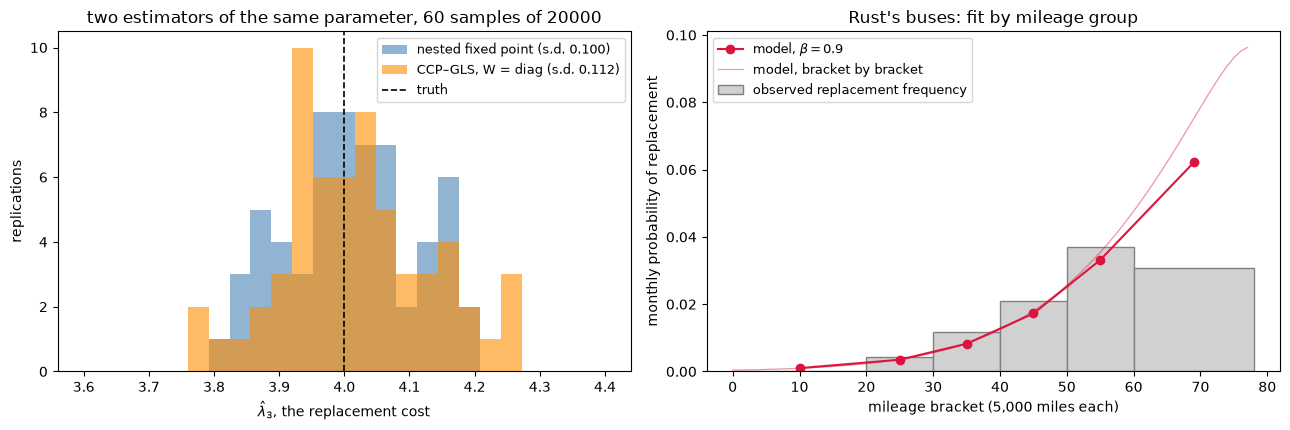

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))

a = ax[0]
bins = np.linspace(3.6, 4.4, 26)
a.hist(mc[:, 2], bins=bins, alpha=0.6, color='steelblue',
       label=f'nested fixed point (s.d. {mc[:, 2].std(ddof=1):.3f})')
a.hist(gls_mc[ok, 2], bins=bins, alpha=0.6, color='darkorange',
       label=f'CCP–GLS, W = diag (s.d. {gls_mc[ok, 2].std(ddof=1):.3f})')
a.axvline(lam_true[2], color='k', ls='--', lw=1.2, label='truth')
a.set_xlabel('$\\hat\\lambda_3$, the replacement cost')
a.set_ylabel('replications')
a.legend(fontsize=9)
a.set_title(f'two estimators of the same parameter, {R} samples of {I}')

b = ax[1]
ctr = [(lo + hi) / 2 for lo, hi in zip(edges[:-1], edges[1:])]
wd = [hi - lo for lo, hi in zip(edges[:-1], edges[1:])]
emp = [muR.reshape(XR, 2)[lo:hi, 1].sum() / max(nx_obs[lo:hi].sum(), 1)
       for lo, hi in zip(edges[:-1], edges[1:])]
mdl = [(nx_obs[lo:hi] * pi_R[lo:hi]).sum() / max(nx_obs[lo:hi].sum(), 1)
       for lo, hi in zip(edges[:-1], edges[1:])]
b.bar(ctr, emp, width=wd, color='0.82', edgecolor='0.5',
      label='observed replacement frequency')
b.plot(ctr, mdl, 'o-', color='crimson', label='model, $\\beta = 0.9$')
b.plot(np.arange(XR), pi_R, color='crimson', lw=0.9, alpha=0.45,
       label='model, bracket by bracket')
b.set_xlabel('mileage bracket (5,000 miles each)')
b.set_ylabel('monthly probability of replacement')
b.legend(fontsize=9)
b.set_title("Rust's buses: fit by mileage group")

plt.tight_layout()
plt.show()

*Left.* The sampling distributions of the two estimators of the replacement cost, over the same simulated samples. Both are centred on the truth; the nested fixed point is the tighter of the two, though not by much once the GLS estimator is weighted by the cell counts. What the picture does not show is the replications in which the CCP estimator did not exist at all.

*Right.* The fit on Rust's data. The observed replacement frequency rises from zero below 100,000 miles to about 3.7% a month in the 250,000–300,000 bracket, and the model tracks it — 61.5 predicted replacements against 60 observed. The one visible discrepancy is at the top: the smooth curve keeps rising past bracket 60, and the model expects a 6.2% monthly hazard there against the 3.1% actually observed. Those brackets hold 228 of 8,156 observations and 7 replacements, so the discrepancy is within sampling error, but it is in the direction one would expect if a linear operating cost overstates how bad a very old engine is.

## Summing up

* In an infinite-horizon problem, stationarity turns backward induction into a Bellman fixed point. Discounting makes the Bellman operator a contraction with modulus $\beta$.
* A stationary policy induces a stationary distribution, obtained as a Perron eigenvector and approached geometrically from any initial distribution.
* Nested fixed-point estimation differentiates through the Bellman equation. MPEC imposes that equation as a constraint, and its multiplier is the occupation measure.
* Without additional restrictions, dynamic choice probabilities leave an $X$-dimensional affine set of payoff parameters observationally equivalent. The weak profile in $\beta$ on Rust's data makes this failure visible.
* Hotz and Miller replace repeated fixed-point solution by conditional-choice-probability inversion. The gain in speed comes with efficiency loss and fragility when empirical cells are empty.


## Exercises

**1. (Theory and computation — the unit-discounting limit.)** Remark 6.7 states that when $\beta=1$ the stationary equations are the first-order conditions of the saddle-point problem $\min_{u\in\mathbb{R}^X}\max_{n\in\Delta_X}Z(u,u,n)$. (i) Show that at $\beta=1$ the inner maximum is $\max_x\{\sum_y\exp(\phi_{xy}+(\mathbf{P}^\top u)_{xy}-u_x)-1\}$, so the problem is a minimax over a piecewise-smooth function. (ii) Explain why $u$ is determined only up to an additive constant, and why the problem has a solution only if the long-run average payoff is zero. (iii) Modify $\phi$ so that it is, solve the minimax numerically, and compare the resulting $n$ to the $\beta\to1$ limit of $n^\star$ computed in section 1.

**2. (Computation — how much does the nested fixed point need to converge?)** Section 2 solves the Bellman equation to $10^{-13}$ at every trial $\lambda$. Replace the inner tolerance by $10^{-4}$, $10^{-6}$, $10^{-8}$ and record, for each: the number of outer BFGS iterations, the total number of inner Bellman iterations, and $|\hat\lambda-\hat\lambda_{\text{exact}}|$. (i) Find the tolerance that minimizes total inner iterations subject to four correct digits in $\hat\lambda$. (ii) Implement a *warm start*, passing the previous $u$ as the initial guess, and repeat. (iii) Compare the best of these to the MPEC of section 3, and explain why the ranking depends on $X$.

**3. (Econometrics — is $\beta$ identified?)** Section 6 profiled the likelihood in $\beta$ and found it nearly flat. (i) Compute the profile likelihood on a fine grid of $\beta\in[0,0.995]$ and construct a likelihood-ratio confidence interval for $\beta$. Is it informative? (ii) Magnac and Thesmar (2002) show that $\beta$ is identified when an *exclusion restriction* is available — a state variable that shifts transitions but not current payoffs. Add such a variable to the simulated design of sections 1–2 (for example a second dimension of the state that affects only $\mathbf{P}$), and show by Monte Carlo that $\beta$ becomes estimable. (iii) How large a sample is needed for a standard error on $\beta$ below $0.05$?

**4. (Computation — the CCP estimator with sparse data.)** The CCP estimator fails on Rust's data because 40 brackets contain no replacement. (i) Coarsen the state space by grouping brackets into bins of 3, 5 and 10, and report at which coarseness every cell becomes non-empty. (ii) For each coarsening, compute the CCP–GLS estimate and compare it to the nested fixed-point estimate on the *same* coarsening. (iii) Coarsening changes the model, not just the estimator: quantify the bias it introduces by coarsening the *simulated* design of section 2, where the truth is known.

**5. (Economics — what does the estimate say about maintenance policy?)** Using the $\beta=0.9$ estimate of section 6: (i) compute the stationary distribution of mileage implied by the model and compare it to the empirical distribution across the 104 buses; (ii) compute the long-run average cost per month, and the mileage at which the manager is *dynamically* indifferent, defined as the bracket where $\pi_{x,\text{replace}}=1/2$; (iii) a regulator forces replacement at or before bracket 40. Impose it as a capacity-style constraint in the manner of lecture 9, recompute the policy, and report the change in long-run average cost. (iv) Repeat (iii) at $\beta=0.99$ and comment on how much the policy recommendation depends on a parameter the data barely identify.

---

### Run notes

`FAST_MODE = True` uses 60 Monte Carlo replications and a four-point $\beta$ profile; `False` uses 200 and six. Every assertion holds in both modes. The notebook uses numpy, scipy and matplotlib only, and loads Rust's data from a local `mec_datasets` checkout when available, otherwise from the public repository.

Listings `6-05`, `6-06` and `6-07` all draw $\hat\mu_{xy}$ from `np.random.uniform`, unrelated to the model, so the $\hat\lambda$ they print has no interpretation and the estimators cannot be checked against a truth. Sections 2, 3 and 5 simulate from a known $\lambda$ instead, which is what makes the Monte Carlo comparisons of sections 2 and 5 possible.

Three departures from the printed text are worth recording. Listing `6-05` runs the inner fixed point for a fixed count $S$ derived from the contraction bound, with no early exit; section 1 measures $S$ against what is actually needed and finds a factor of four at $\beta=0.9$, growing to thirty-two at $\beta=0.99$. Listing `6-07` builds $\mathbf{A}=\mathbf{I}+\mathbf{\Psi}(\mathbf{\delta}^1\mathbf{\Psi})^{-1}\mathbf{\delta}^1$, where theorem 6.13 has a minus sign; section 5 evaluates both on choice probabilities computed from a known $\phi$, and only the theorem's version inverts them.

The displayed score, $d\ell=\hat\mu^\top(\mathbf{I}_{XY}-(\mathbf{\Sigma}_Y\mathbf{\Delta}_\pi\mathbf{\Psi})^{-1}\mathbf{\Sigma}_Y\mathbf{\Delta}_\pi)\Phi$, does not conform: $\mathbf{I}_{XY}$ is $XY\times XY$ while the term subtracted from it is $X\times XY$. The missing factor is $\mathbf{\Psi}$, giving $\hat\mu^\top(\mathbf{I}_{XY}-\mathbf{\Psi}(\mathbf{\Sigma}_Y\mathbf{\Delta}_\pi\mathbf{\Psi})^{-1}\mathbf{\Sigma}_Y\mathbf{\Delta}_\pi)\Phi=\hat\mu^\top(\Phi+\mathbf{\Psi}du)$, which is what listing `6-05` computes and what section 2 verifies against finite differences.

Listing `6-08` flattens the bus panels into a single column, which interleaves buses and makes $x_t$ and $x_{t+1}$ impossible to pair. Section 6 keeps the panel shape and forms the transitions explicitly; the increment distribution and the counts $\hat\mu_{xy}$ are unaffected, but the transition matrix could not be built otherwise.

**Next:** lecture 11 returns to static choice and adds constraints on the *options* rather than on time — rationing, waiting lines, and the multiplier that prices a queue.